# Float Student Default Checkpoints

This notebook inspects the current strong float-student defaults shipped by
HydraNet for:

- `anomaly_detection`
- `burned_area`
- `fire`
- `worldfloods`

Current catalog contract:

- each of these experts keeps only the strong `finetuning` `5000-shot`
  student checkpoint
- weaker `linear_probing` and lower-shot student variants are no longer part
  of the default workflow

The notebook uses the corrected float export at
`outputs/routerset/fix30March_floatminmax_selected_anomalyfix/` and renders
representative `train` and `validation` patches for each expert.


In [1]:
from __future__ import annotations

import contextlib
import io
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython import get_ipython
from IPython.display import Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from hydranet import load_student
from hydranet.moe_training import _reduce_expert_output_to_routing_score

DATASET_ROOT = PROJECT_ROOT / 'outputs' / 'routerset' / 'fix30March_floatminmax_selected_anomalyfix'
MANIFEST_PATH = DATASET_ROOT / 'manifest_256.jsonl'
REPORT_PATH = DATASET_ROOT / 'student_default_checkpoint_summary.json'

EXPERTS = ['anomaly_detection', 'burned_area', 'fire', 'worldfloods']
VARIANT = {'label': 'FT-5000', 'training': 'finetuning', 'n_shots': 5000}
DEVICE = 'cpu'

torch.set_grad_enabled(False)
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')
set_matplotlib_formats('png')
plt.rcParams['figure.figsize'] = (14, 4.5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.max_open_warning'] = 0

print('project_root:', PROJECT_ROOT)
print('dataset_root:', DATASET_ROOT)
print('manifest_exists:', MANIFEST_PATH.exists())
print('variant:', VARIANT)


project_root: /shared/home/rdelprete/PythonProjects/hydranet-phisat2
dataset_root: /shared/home/rdelprete/PythonProjects/hydranet-phisat2/outputs/routerset/fix30March_floatminmax_selected_anomalyfix
manifest_exists: True
variant: {'label': 'FT-5000', 'training': 'finetuning', 'n_shots': 5000}


In [2]:
FALSE_RGB_CHANNELS = (4, 2, 1)  # B08, B04, B03


def load_manifest_rows(path: Path) -> list[dict]:
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]


def resolve_path(value: str | Path) -> Path:
    path = Path(value)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def normalize_display(chw: np.ndarray, channels: tuple[int, int, int]) -> np.ndarray:
    rgb = np.stack([chw[index] for index in channels], axis=-1).astype(np.float32)
    lo = np.percentile(rgb, 2.0)
    hi = np.percentile(rgb, 98.0)
    if hi <= lo:
        return np.clip(rgb, 0.0, 1.0)
    rgb = (rgb - lo) / (hi - lo)
    return np.clip(rgb, 0.0, 1.0)


def infer_patch(model: torch.nn.Module, chw: np.ndarray) -> dict:
    x = torch.from_numpy(np.array(chw, copy=True)).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(dim=1)[0].detach().cpu().numpy()
    conf = probs.max(dim=1).values[0].detach().cpu().numpy()
    score = _reduce_expert_output_to_routing_score(logits.detach().cpu())
    values, counts = np.unique(pred, return_counts=True)
    histogram = {int(v): int(c) for v, c in zip(values, counts)}
    return {
        'pred': pred,
        'conf': conf,
        'score': float(score),
        'histogram': histogram,
        'mean_conf': float(np.mean(conf)),
    }


def markdown_table(rows: list[dict], columns: list[tuple[str, str]]) -> str:
    header = '| ' + ' | '.join(label for _, label in columns) + ' |'
    divider = '| ' + ' | '.join(['---'] * len(columns)) + ' |'
    body = []
    for row in rows:
        body.append('| ' + ' | '.join(str(row[key]) for key, _ in columns) + ' |')
    return '\n'.join([header, divider, *body])


In [3]:
rows = load_manifest_rows(MANIFEST_PATH)
rows_by_expert_split: dict[tuple[str, str], list[dict]] = {}
for row in rows:
    expert = row['source_dataset']
    split = row.get('moe_split', row['source_split'])
    if expert not in EXPERTS:
        continue
    rows_by_expert_split.setdefault((expert, split), []).append(row)

selected_rows: list[dict] = []
for expert in EXPERTS:
    for split in ('train', 'validation'):
        group = sorted(
            rows_by_expert_split[(expert, split)],
            key=lambda row: (str(row['source_sample_id']), str(row['materialized_image_path'])),
        )
        selected_rows.append(group[0])

print(json.dumps([
    {
        'expert': row['source_dataset'],
        'split': row.get('moe_split', row['source_split']),
        'sample_id': row['source_sample_id'],
        'labels': row.get('label_names') or [],
        'materialized_image_path': row['materialized_image_path'],
    }
    for row in selected_rows
], indent=2))


[
  {
    "expert": "anomaly_detection",
    "split": "train",
    "sample_id": "0000000",
    "labels": [
      "water"
    ],
    "materialized_image_path": "outputs/routerset/fix30March_floatminmax_selected_anomalyfix/images/anomaly_detection/train/0000000_0_0_256_256.npy"
  },
  {
    "expert": "anomaly_detection",
    "split": "validation",
    "sample_id": "0000001",
    "labels": [
      "cloud",
      "land",
      "marine_algae",
      "turbid_water"
    ],
    "materialized_image_path": "outputs/routerset/fix30March_floatminmax_selected_anomalyfix/images/anomaly_detection/validation/0000001_0_0_256_256.npy"
  },
  {
    "expert": "burned_area",
    "split": "train",
    "sample_id": "0000002",
    "labels": [],
    "materialized_image_path": "outputs/routerset/fix30March_floatminmax_selected_anomalyfix/images/burned_area/train/0000002_0_0_256_256.npy"
  },
  {
    "expert": "burned_area",
    "split": "validation",
    "sample_id": "0000075",
    "labels": [],
    "materializ

In [4]:
models = {}
model_logs = {}
for expert in EXPERTS:
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        model = load_student(
            task=expert,
            training=VARIANT['training'],
            n_shots=VARIANT['n_shots'],
            auto_load_weights=True,
        )
    model.eval()
    model.to(DEVICE)
    models[expert] = model
    model_logs[expert] = [line for line in buffer.getvalue().splitlines() if line.strip()]

for expert in EXPERTS:
    print(f"{expert}: {model_logs[expert][-1] if model_logs[expert] else 'loaded'}")


anomaly_detection:   Adjusted n_classes to checkpoint head: 9
burned_area:   Adjusted n_classes to checkpoint head: 4
fire:   Note: 4 keys in checkpoint not used (e.g., task-specific heads)
worldfloods: Loading weights from: /shared/home/rdelprete/.cache/huggingface/hub/datasets--sirbastiano94--hydranet/snapshots/a2ae755b4f5ddd2e25a9292c677b7c1f6616e065/finetuning/hydranet/worldfloods_nshot5000_frozen/worldfloods/20251212_UNet_Myriad2_Downstream_unfrozen_5000/UNet_Myriad2_Downstream_unfrozen_best.pt


## anomaly_detection | train | `0000000`

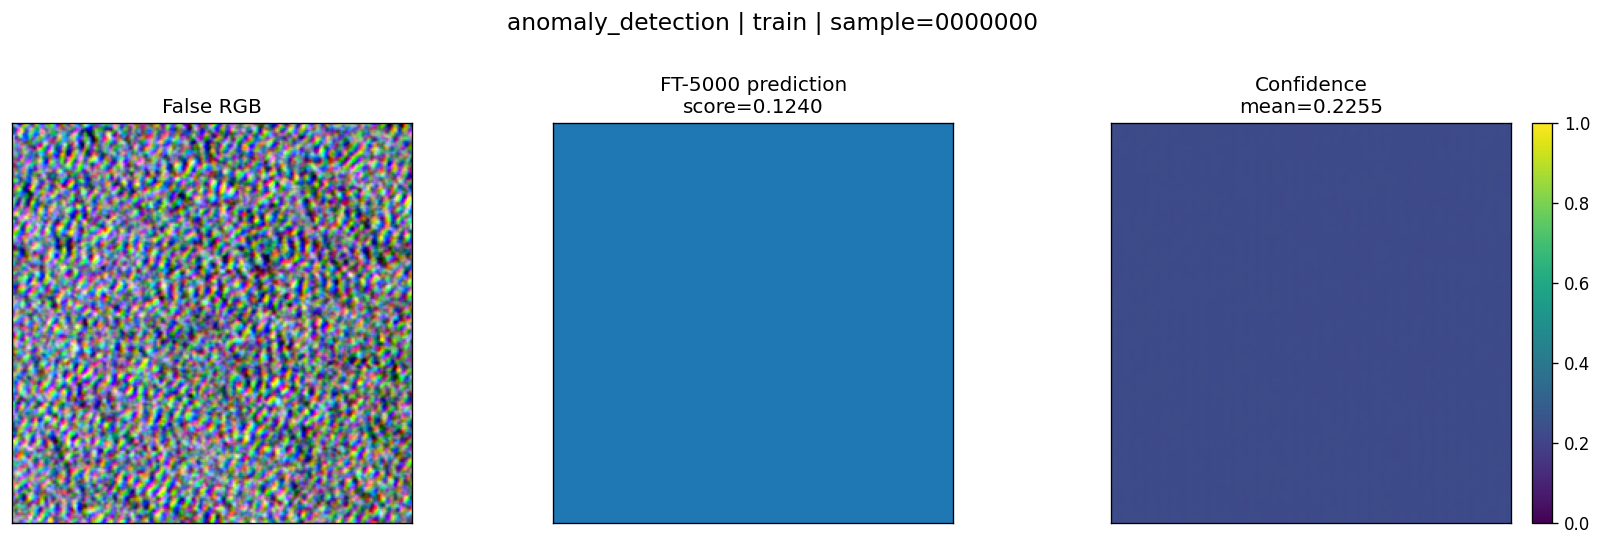

| variant | routing score | mean confidence | pred histogram |
| --- | --- | --- | --- |
| FT-5000 | 0.1240 | 0.2255 | {1: 65536} |

## anomaly_detection | validation | `0000001`

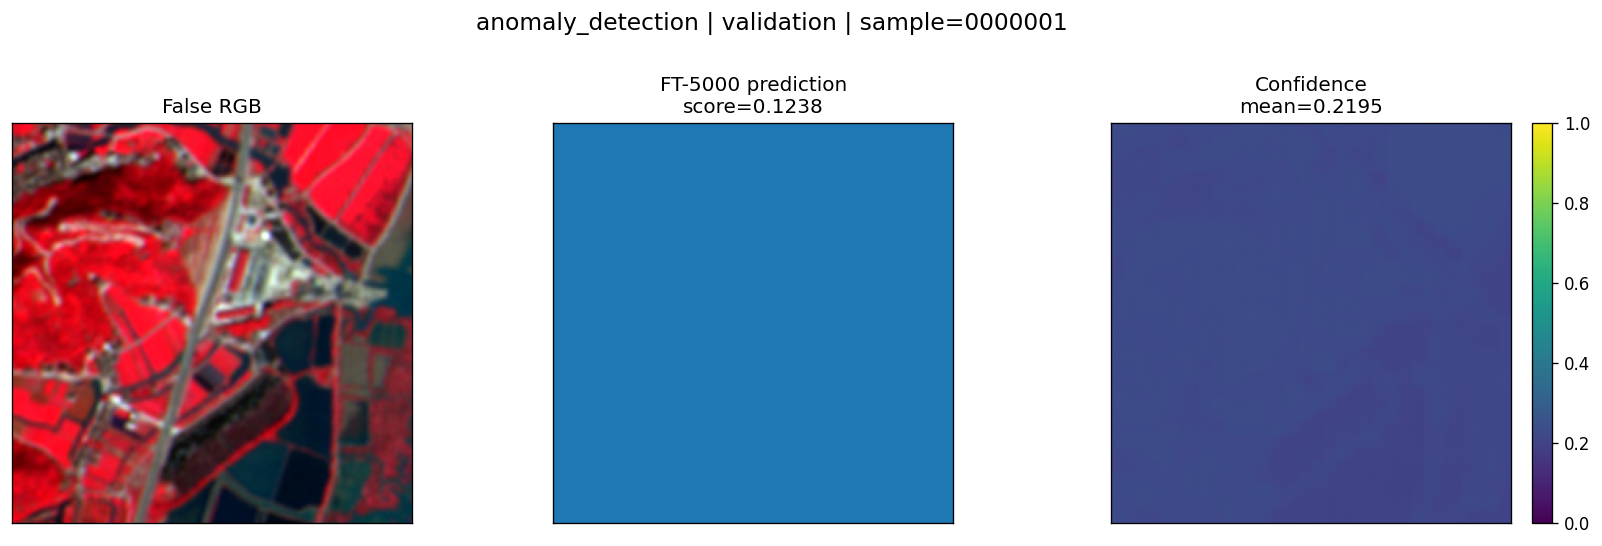

| variant | routing score | mean confidence | pred histogram |
| --- | --- | --- | --- |
| FT-5000 | 0.1238 | 0.2195 | {1: 65536} |

## burned_area | train | `0000002`

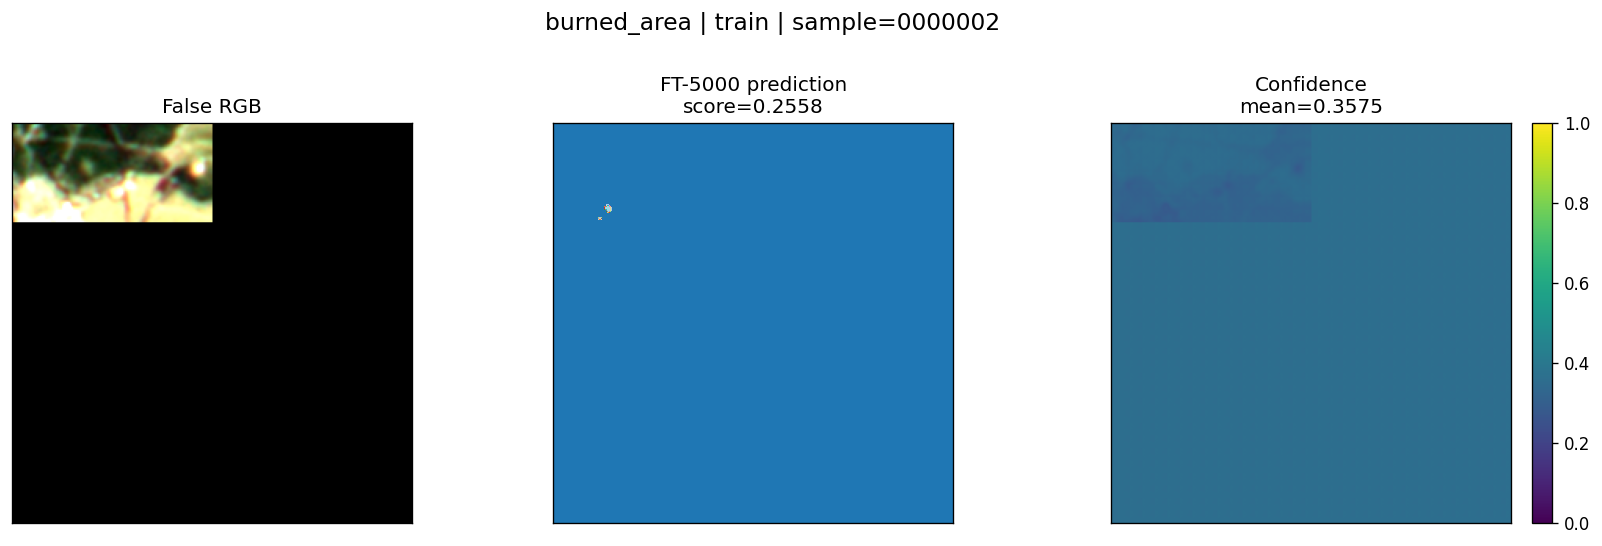

| variant | routing score | mean confidence | pred histogram |
| --- | --- | --- | --- |
| FT-5000 | 0.2558 | 0.3575 | {1: 65520, 2: 16} |

## burned_area | validation | `0000075`

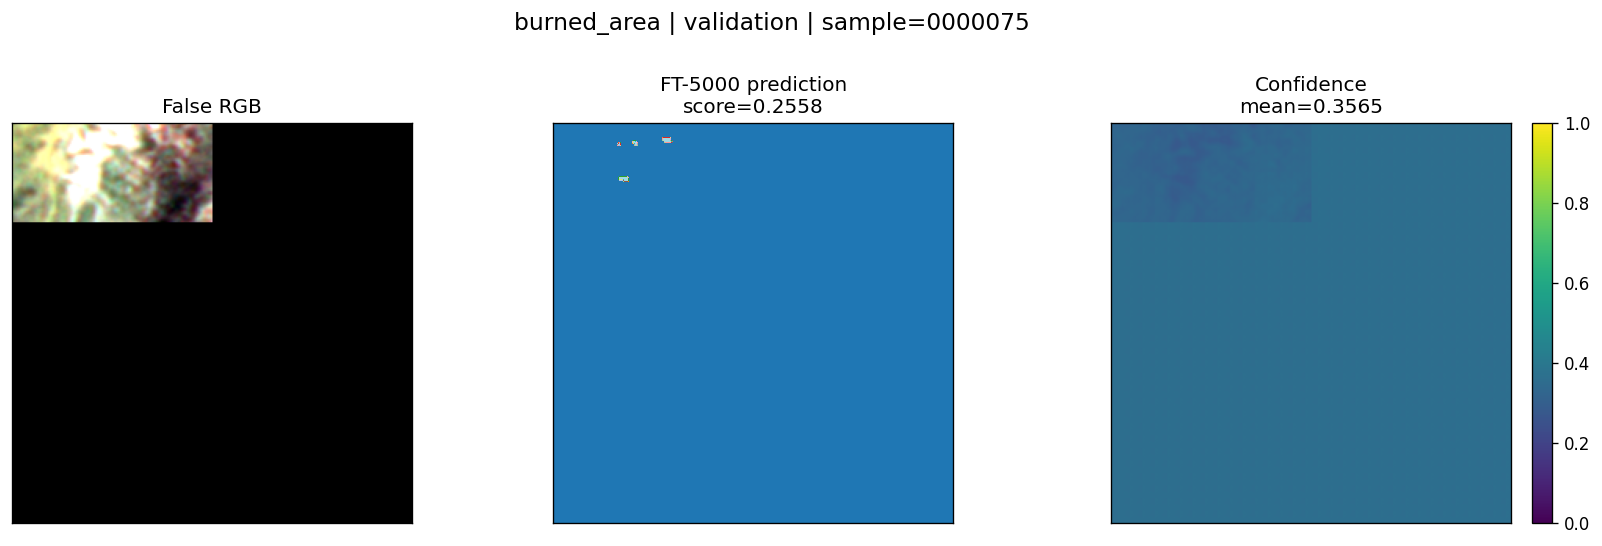

| variant | routing score | mean confidence | pred histogram |
| --- | --- | --- | --- |
| FT-5000 | 0.2558 | 0.3565 | {1: 65496, 2: 40} |

## fire | train | `0000000`

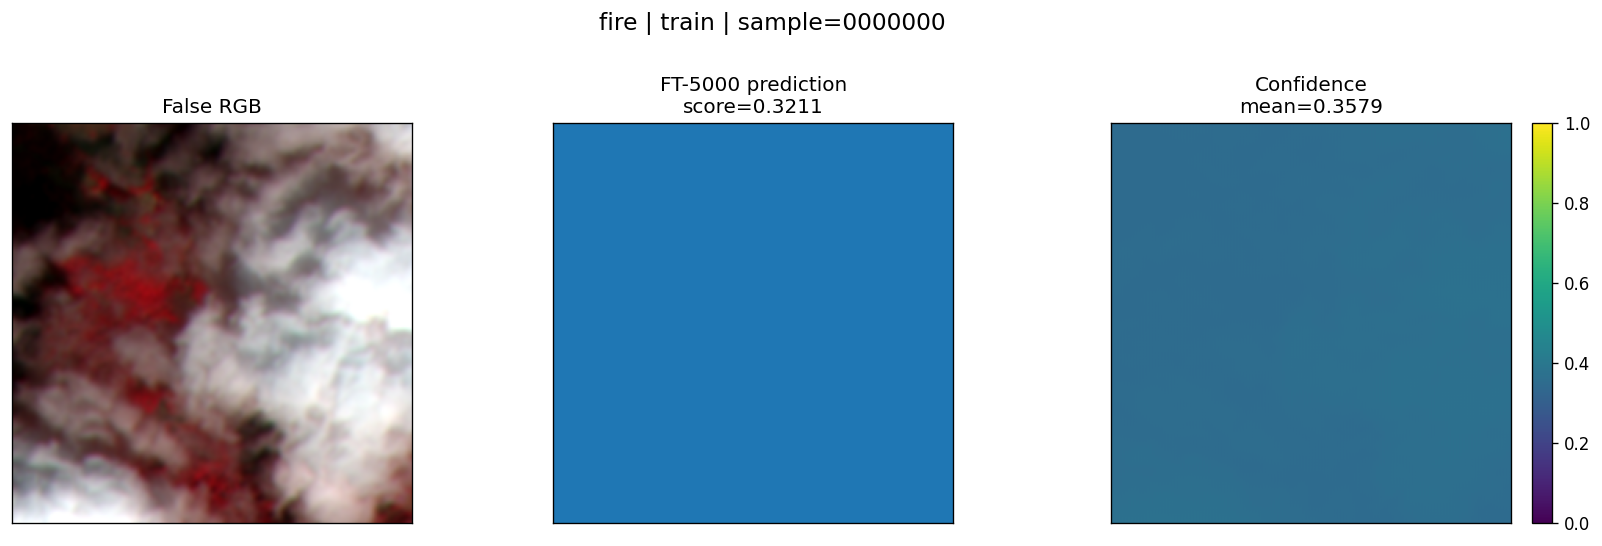

| variant | routing score | mean confidence | pred histogram |
| --- | --- | --- | --- |
| FT-5000 | 0.3211 | 0.3579 | {0: 65536} |

## fire | validation | `0000005`

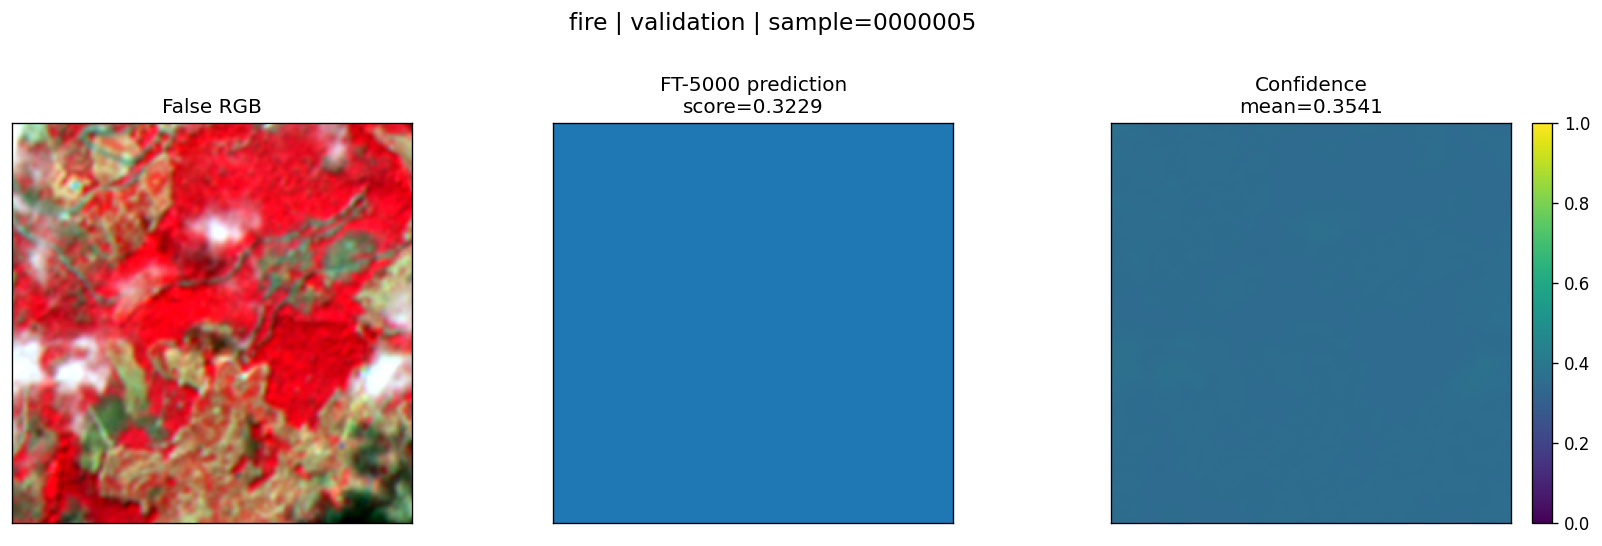

| variant | routing score | mean confidence | pred histogram |
| --- | --- | --- | --- |
| FT-5000 | 0.3229 | 0.3541 | {0: 65536} |

## worldfloods | train | `0000071`

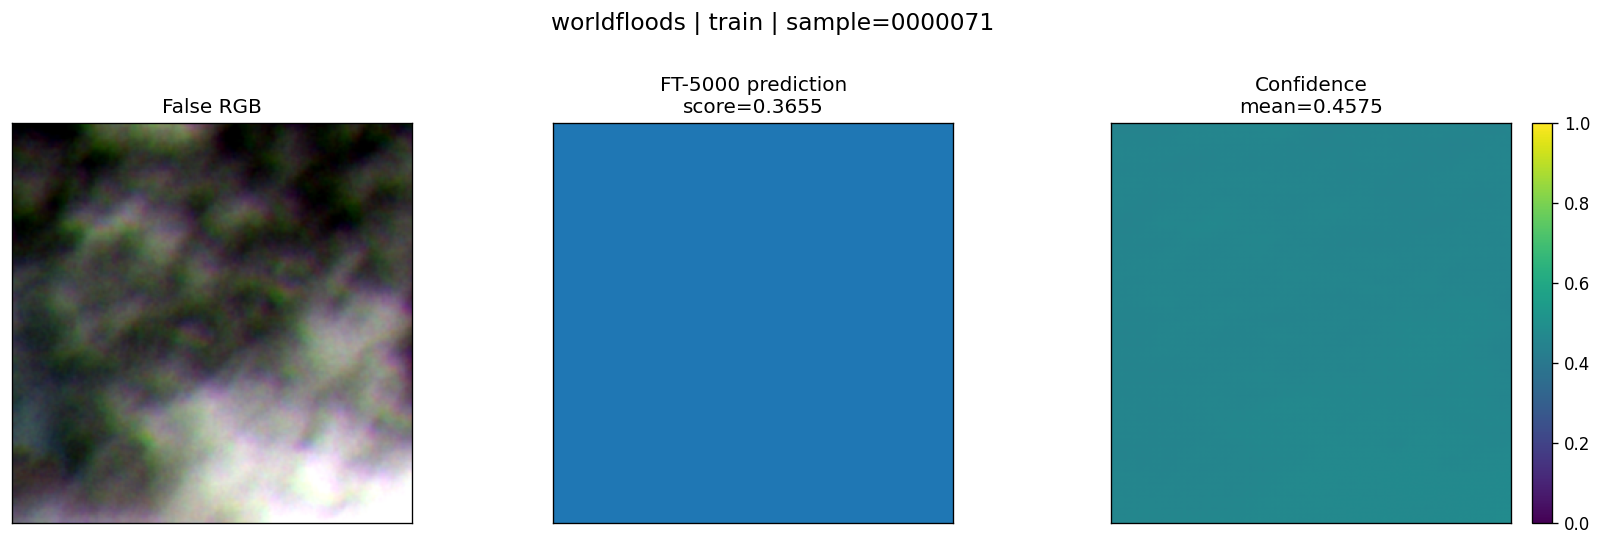

| variant | routing score | mean confidence | pred histogram |
| --- | --- | --- | --- |
| FT-5000 | 0.3655 | 0.4575 | {1: 65536} |

## worldfloods | validation | `0000803`

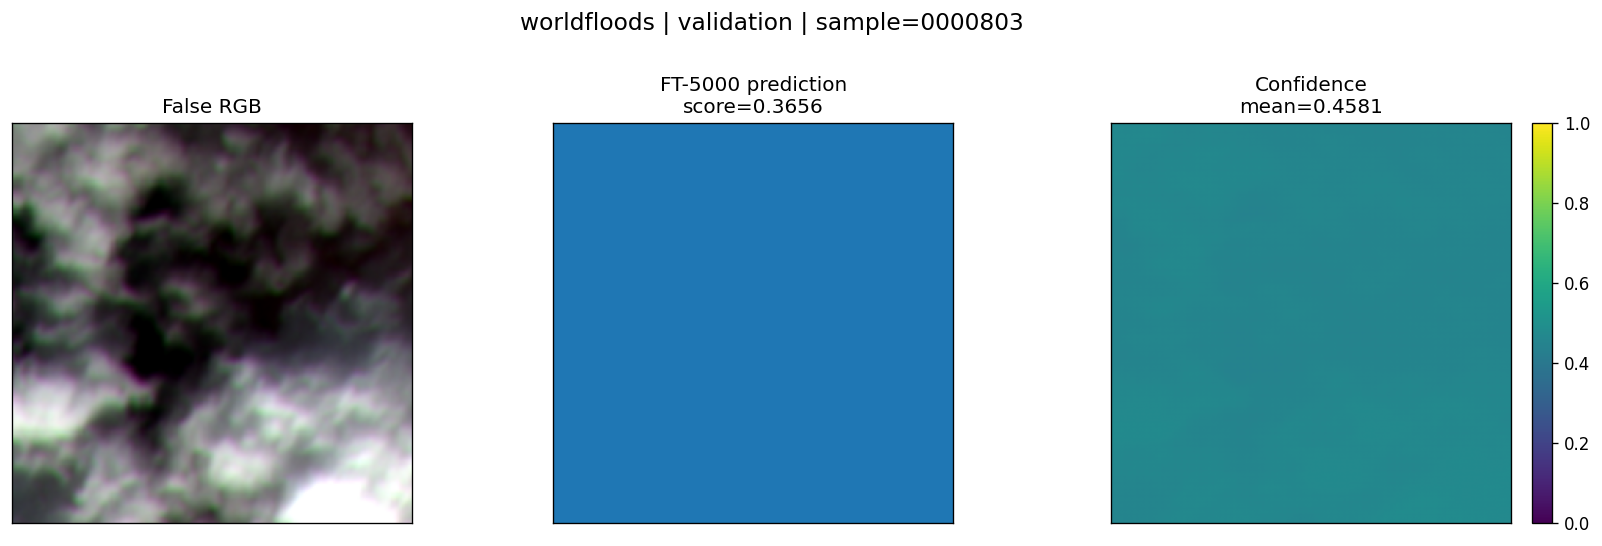

| variant | routing score | mean confidence | pred histogram |
| --- | --- | --- | --- |
| FT-5000 | 0.3656 | 0.4581 | {1: 65536} |

summary_report: /shared/home/rdelprete/PythonProjects/hydranet-phisat2/outputs/routerset/fix30March_floatminmax_selected_anomalyfix/student_default_checkpoint_summary.json


In [5]:
report = {'dataset_root': str(DATASET_ROOT), 'variant': VARIANT, 'per_patch': []}

for row in selected_rows:
    expert = row['source_dataset']
    split = row.get('moe_split', row['source_split'])
    image = np.load(resolve_path(row['materialized_image_path'])).astype(np.float32, copy=False)
    result = infer_patch(models[expert], image)

    report['per_patch'].append(
        {
            'expert': expert,
            'split': split,
            'sample_id': row['source_sample_id'],
            'score': result['score'],
            'mean_conf': result['mean_conf'],
            'histogram': result['histogram'],
        }
    )

    display(Markdown(f"## {expert} | {split} | `{row['source_sample_id']}`"))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    fig.suptitle(f"{expert} | {split} | sample={row['source_sample_id']}", fontsize=14)

    axes[0].imshow(normalize_display(image, FALSE_RGB_CHANNELS))
    axes[0].set_title('False RGB')

    axes[1].imshow(result['pred'], cmap='tab20')
    axes[1].set_title(f"{VARIANT['label']} prediction\nscore={result['score']:.4f}")

    im = axes[2].imshow(result['conf'], cmap='viridis', vmin=0.0, vmax=1.0)
    axes[2].set_title(f"Confidence\nmean={result['mean_conf']:.4f}")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

    display(
        Markdown(
            markdown_table(
                [
                    {
                        'variant': VARIANT['label'],
                        'score': f"{result['score']:.4f}",
                        'mean_conf': f"{result['mean_conf']:.4f}",
                        'histogram': result['histogram'],
                    }
                ],
                [
                    ('variant', 'variant'),
                    ('score', 'routing score'),
                    ('mean_conf', 'mean confidence'),
                    ('histogram', 'pred histogram'),
                ],
            )
        )
    )

REPORT_PATH.write_text(json.dumps(report, indent=2), encoding='utf-8')
print('summary_report:', REPORT_PATH)
